# Threadle — demo de producto

> «Todo parece funcionar… hasta que deja de hacerlo.»

**Qué problema ataca threadle:** bugs de concurrencia que no dejan stack trace bonito: contención, deadlocks, diseños frágiles.

**Qué obtienes:** instrumentación con `TrackedLock`, análisis (`analyze_deadlocks`), y visualización — **grafo de espera** + **Gantt** (threads) o **dependencias + Gantt async** (asyncio).

**Narrativa de este notebook:** (1) introducción y toolkit → (2) sistema sano → (3–7) escenarios progresivos → (4–5) fallos críticos con corrección → (8–9) async → (10) mini sistema → conclusión. Al final, un bloque **Automated validation** genera PNGs bajo `outputs/` para CI y documentación.

**Colores (Gantt semántico):** *running* → verde · *waiting* → rojo/naranja · *holding lock* → azul.


In [ ]:
!pip install threadle matplotlib networkx

In [1]:
import asyncio
import threading
import time
from collections import defaultdict

from IPython.display import Markdown, display

import threadle as tl
from threadle.analysis.graph import build_graph


def reset_state():
    tl.clear_events()
    tl.clear_async_events()


def run_coro_notebook_safe(coro, timeout=20.0):
    """Ejecuta coroutines en Jupyter/Colab aunque ya exista un event loop."""
    try:
        asyncio.get_running_loop()
        in_loop = True
    except RuntimeError:
        in_loop = False
    if not in_loop:
        return asyncio.run(coro)
    box = {"result": None, "error": None}

    def _runner():
        try:
            box["result"] = asyncio.run(coro)
        except Exception as exc:
            box["error"] = exc

    t = threading.Thread(target=_runner, daemon=True)
    t.start()
    t.join(timeout=timeout)
    if t.is_alive():
        raise TimeoutError("La coroutine superó el timeout de seguridad.")
    if box["error"] is not None:
        raise box["error"]
    return box["result"]


def run_thread_scenario(workers, *, snapshot_delay=0.06, join_timeout=2.5):
    reset_state()
    with tl.Session(trace_timeline=True, reset_tracker=True):
        threads = [
            threading.Thread(target=tl.trace_thread(fn), name=name)
            for name, fn in workers
        ]
        for th in threads:
            th.start()
        time.sleep(snapshot_delay)
        hot = tl.analyze_deadlocks()
        # Copia del grafo mientras los hilos siguen vivos (después del join el tracker suele vaciarse).
        graph_hot = build_graph().copy()
        for th in threads:
            th.join(timeout=join_timeout)
        final = tl.analyze_deadlocks()
        events = list(tl.get_events())
        stuck = [th.name for th in threads if th.is_alive()]
    return {
        "hot_report": hot,
        "final_report": final,
        "events": events,
        "stuck": stuck,
        "graph_hot": graph_hot,
    }


def show_thread_results(label: str, result: dict) -> None:
    """Grafo dirigido con :func:`threadle.visualize` + Gantt interactivo."""
    display(Markdown(f"### {label}"))
    display(
        Markdown(
            f"**Resumen (snapshot en caliente):** {result['hot_report'].summary}\n\n"
            f"**Resumen (snapshot final):** {result['final_report'].summary}"
        )
    )
    if result["stuck"]:
        display(Markdown(f"**Threads aún vivos (timeout de seguridad):** `{result['stuck']}`"))
    display(
        Markdown(
            "**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). "
            "Flechas: lock → thread (posee) y thread → lock (espera)."
        )
    )
    tl.visualize(
        graph=result.get("graph_hot"),
        title=f"{label} — grafo dirigido",
        deadlock_report=result["hot_report"],
    )
    display(Markdown("**Gantt (timeline de threads)**"))
    tl.visualize_gantt(
        events=result["events"],
        palette="semantic",
        theme="dark",
        title=f"{label} — Gantt",
    )


def show_async_results(label: str, events: list) -> None:
    """Grafo de dependencias dirigido + Gantt async."""
    display(Markdown(f"### {label}"))
    g = tl.build_async_dependency_graph(events)
    display(Markdown("*Async* · dependencias entre tasks · `tl.visualize`"))
    tl.visualize(graph=g, title=f"{label} — grafo dirigido (tasks / await)")
    display(Markdown("**Gantt async**"))
    tl.visualize_async_gantt(events=events, title=f"{label} — Gantt async")


def learned(text: str) -> None:
    display(Markdown(f"**¿Qué aprendimos?** {text}"))


print("Toolkit listo.")


Toolkit listo.


## Cómo leer las visualizaciones

- **Grafo:** nodos *thread* vs *lock*; flechas rojas *espera*, azules *posee*.
- **Gantt:** franjas de ejecución y espera en el tiempo; busca cuellos de botella antes de culpar a la red.

**Nota (GIL):** en CPython el GIL serializa bytecode; igual observamos *locks lógicos* y esperas — lo que importa para diseño y debugging en servicios reales.

## 1) Sistema sano (baseline)

**Contexto:** Microservicios que comparten un recurso poco disputado.

**Comportamiento esperado:** Sin deadlock; colas cortas.

**Qué mirar:** Gantt mayormente verde; poco rojo.


### 1) Baseline — sistema sano

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

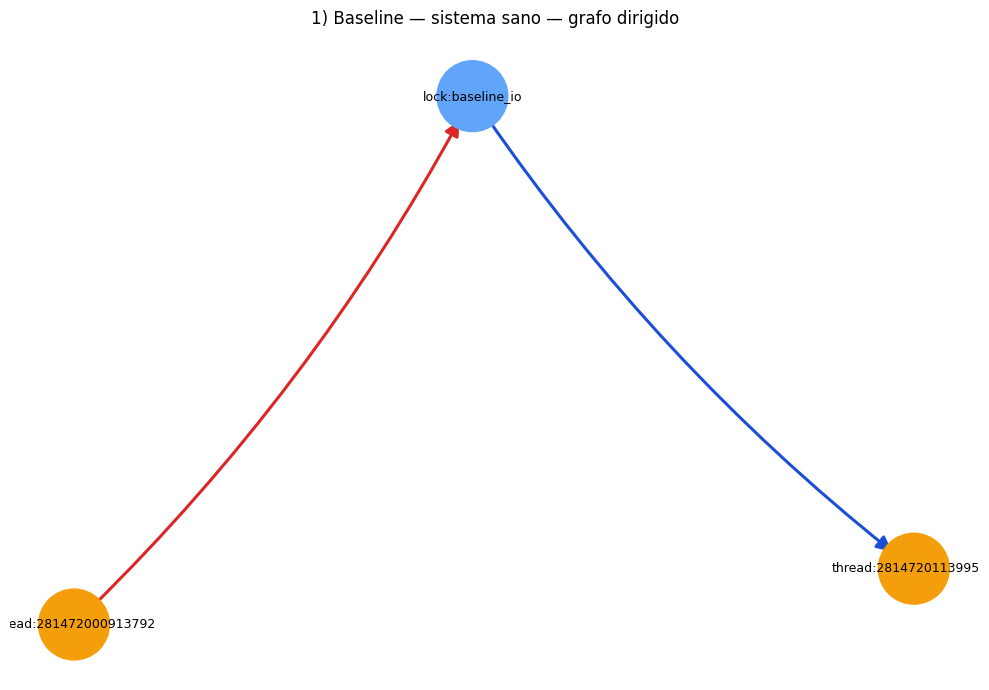

**Gantt (timeline de threads)**

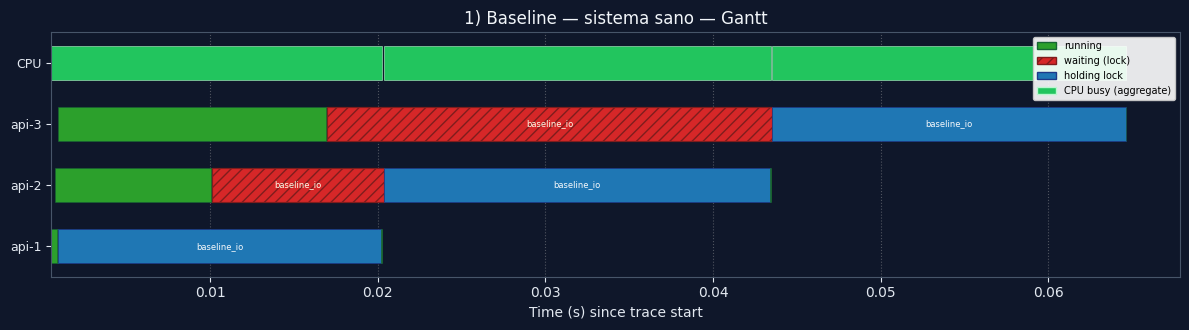

**¿Qué aprendimos?** **Insight:** referencia de un servicio coordinado sin colas dramáticas. **Por qué importa:** sin baseline, todo parece anomalía. **En producción:** entornos con pocos usuarios o caches calientes.

In [2]:
# 1) Baseline — sistema sano
baseline = tl.TrackedLock("baseline_io")

def healthy_worker(delay: float) -> None:
    time.sleep(delay)
    baseline.acquire()
    try:
        time.sleep(0.018)
    finally:
        baseline.release()

r1 = run_thread_scenario(
    [
        ("api-1", lambda: healthy_worker(0.0)),
        ("api-2", lambda: healthy_worker(0.008)),
        ("api-3", lambda: healthy_worker(0.015)),
    ],
    snapshot_delay=0.035,
)
show_thread_results("1) Baseline — sistema sano", r1)
learned(
    "**Insight:** referencia de un servicio coordinado sin colas dramáticas. "
    "**Por qué importa:** sin baseline, todo parece anomalía. "
    "**En producción:** entornos con pocos usuarios o caches calientes."
)


## 2) Contención simple de lock

**Contexto:** Varios workers compiten por un único recurso (inventario, impresora, etc.).

**Comportamiento esperado:** No hay error funcional; sí espera.

**Qué mirar:** El Gantt muestra serialización y cola.


### 2) Contención simple de lock

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

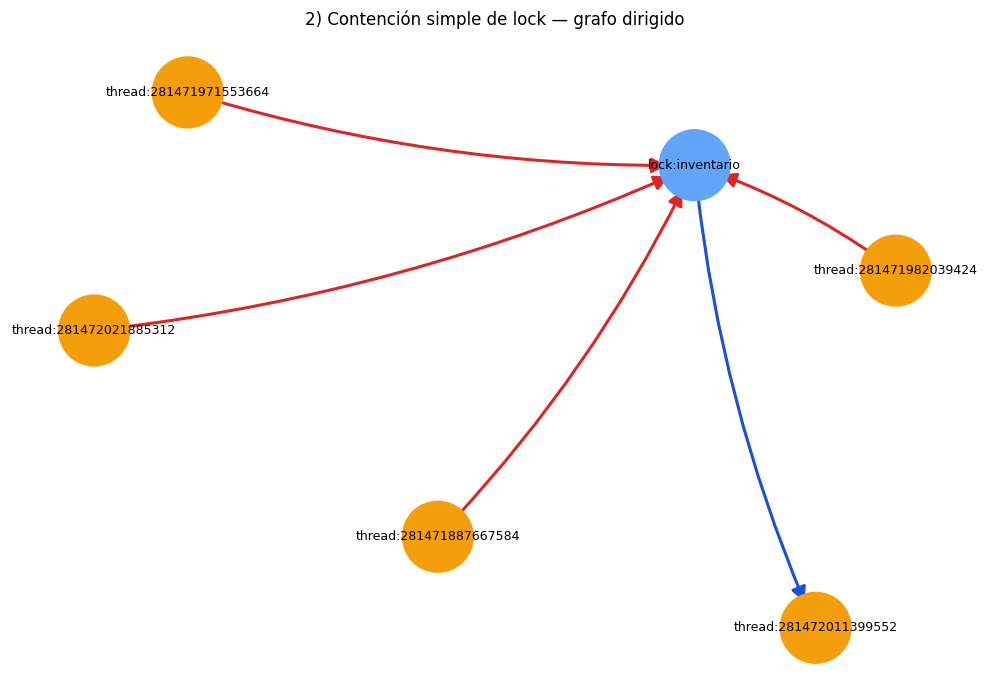

**Gantt (timeline de threads)**

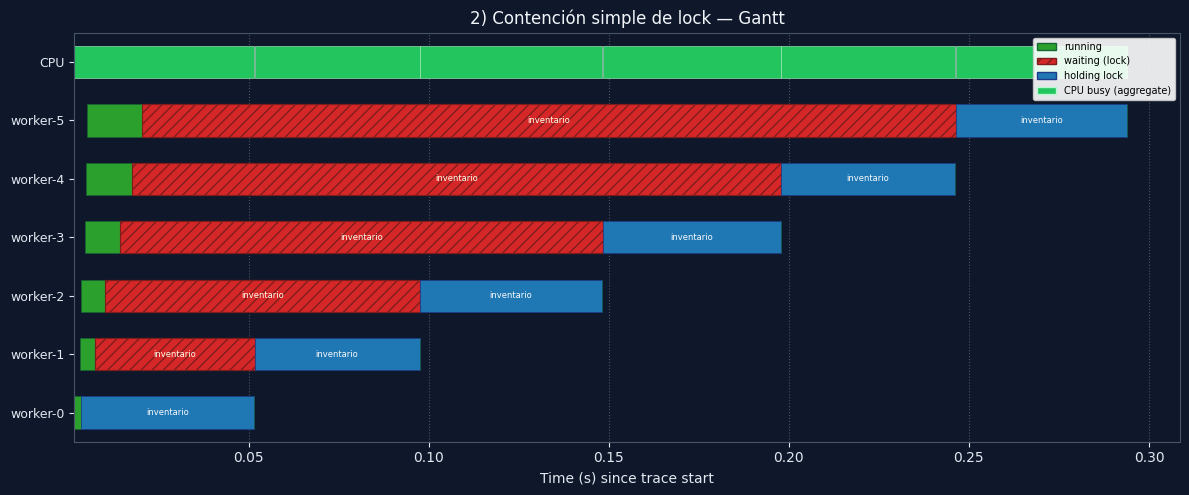

**¿Qué aprendimos?** **Insight:** la latencia crece sin errores explícitos. **Por qué importa:** el Gantt muestra el cuello de botella antes del escalado. **En producción:** picos de p95/p99 en APIs con recurso único.

In [3]:
# 2) Contención simple
inv = tl.TrackedLock("inventario")

def contention_simple(i: int) -> None:
    time.sleep(0.003 * i)
    inv.acquire()
    try:
        time.sleep(0.045)
    finally:
        inv.release()

r2 = run_thread_scenario(
    [(f"worker-{i}", lambda i=i: contention_simple(i)) for i in range(6)],
    snapshot_delay=0.05,
)
show_thread_results("2) Contención simple de lock", r2)
learned(
    "**Insight:** la latencia crece sin errores explícitos. "
    "**Por qué importa:** el Gantt muestra el cuello de botella antes del escalado. "
    "**En producción:** picos de p95/p99 en APIs con recurso único."
)


## 3) Contención severa (degradación)

**Contexto:** Muchos hilos y sección crítica lenta (simula trabajo pesado).

**Comportamiento esperado:** Throughput pobre; colas largas.

**Qué mirar:** Bandas de espera dominan el timeline.


### 3) Contención severa (degradación)

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

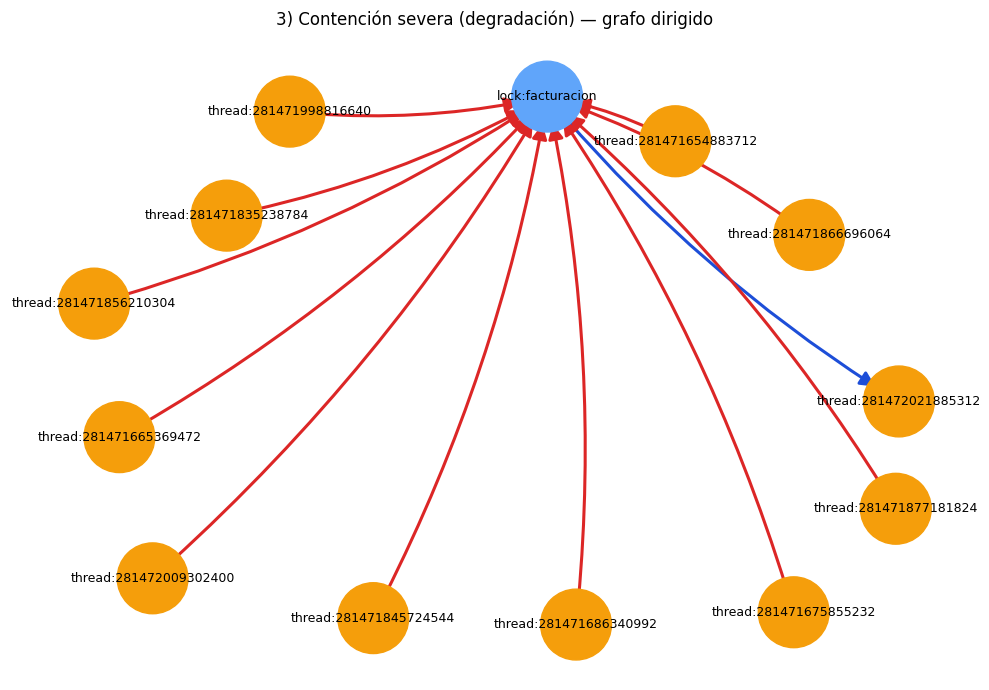

**Gantt (timeline de threads)**

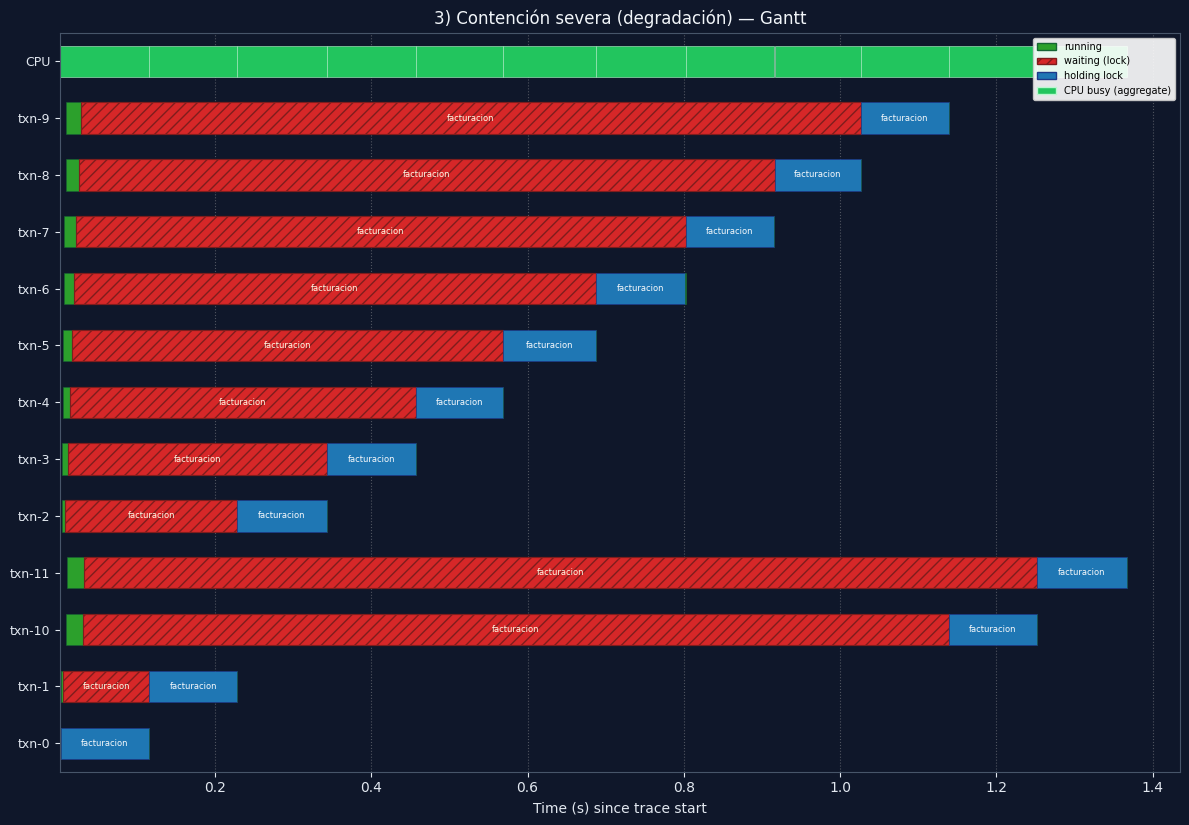

**¿Qué aprendimos?** **Insight:** no hace falta deadlock para matar el throughput. **Por qué importa:** serialización extrema. **En producción:** jobs batch + sección crítica grande.

In [4]:
# 3) Contención severa
bill = tl.TrackedLock("facturacion")

def contention_severe(i: int) -> None:
    time.sleep(0.002 * i)
    bill.acquire()
    try:
        time.sleep(0.11)
    finally:
        bill.release()

r3 = run_thread_scenario(
    [(f"txn-{i}", lambda i=i: contention_severe(i)) for i in range(12)],
    snapshot_delay=0.05,
    join_timeout=4.0,
)
show_thread_results("3) Contención severa (degradación)", r3)
learned(
    "**Insight:** no hace falta deadlock para matar el throughput. "
    "**Por qué importa:** serialización extrema. "
    "**En producción:** jobs batch + sección crítica grande."
)


## 4) Deadlock clásico

**Contexto:** Dos hilos y dos locks en orden cruzado.

**Comportamiento esperado:** Ciclo de espera; timeouts evitan congelar el kernel del notebook.

**Qué mirar:** Grafo con ciclo; luego versión corregida con orden global.


### 4) Deadlock clásico (orden cruzado)

**Resumen (snapshot en caliente):** thread 281471654883712 (t1) holds lock 'A'; thread 281471654883712 (t1) waits for lock 'B'; thread 281471665369472 (t2) holds lock 'B'; thread 281471665369472 (t2) waits for lock 'A'

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

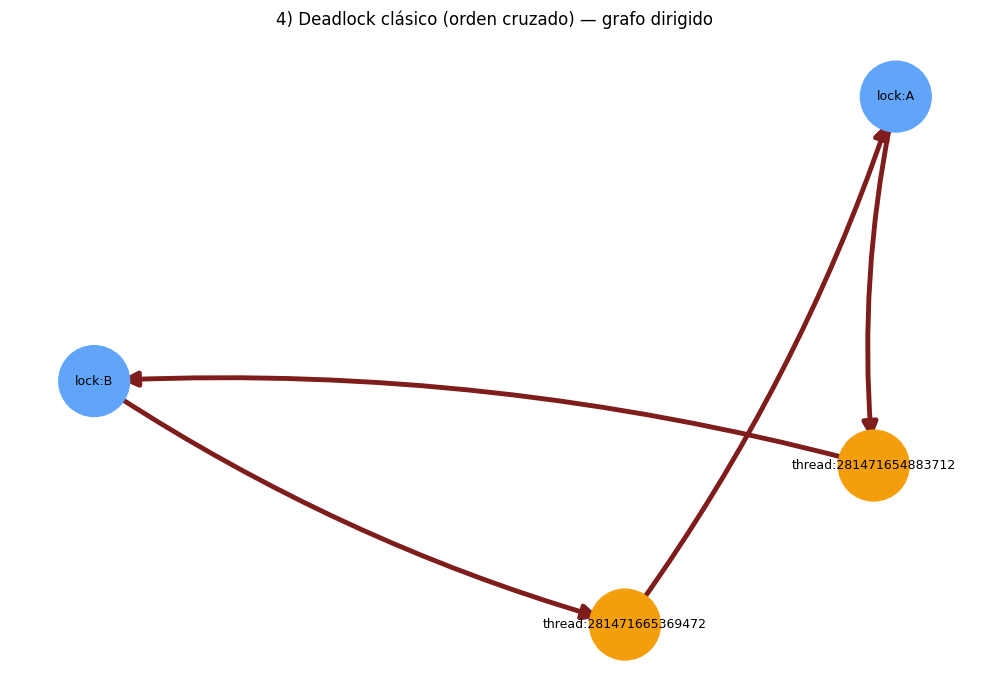

**Gantt (timeline de threads)**

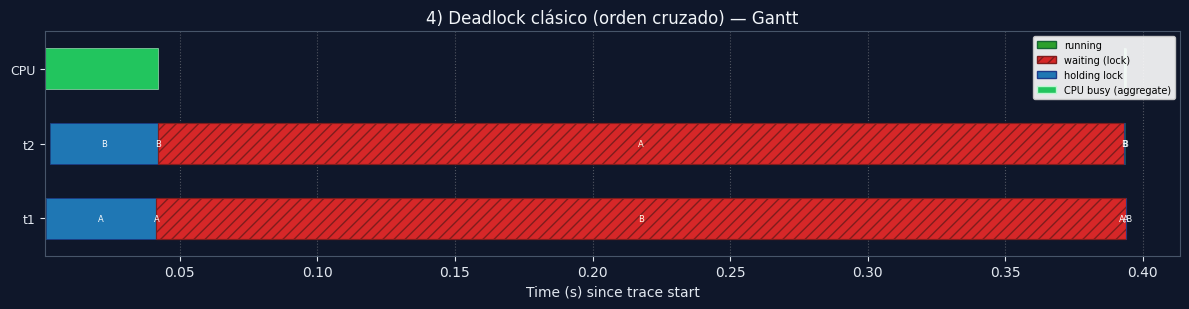

\n>>> Corrección sugerida: orden global A → B\n


### 4) Corregido (mismo orden de locks)

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

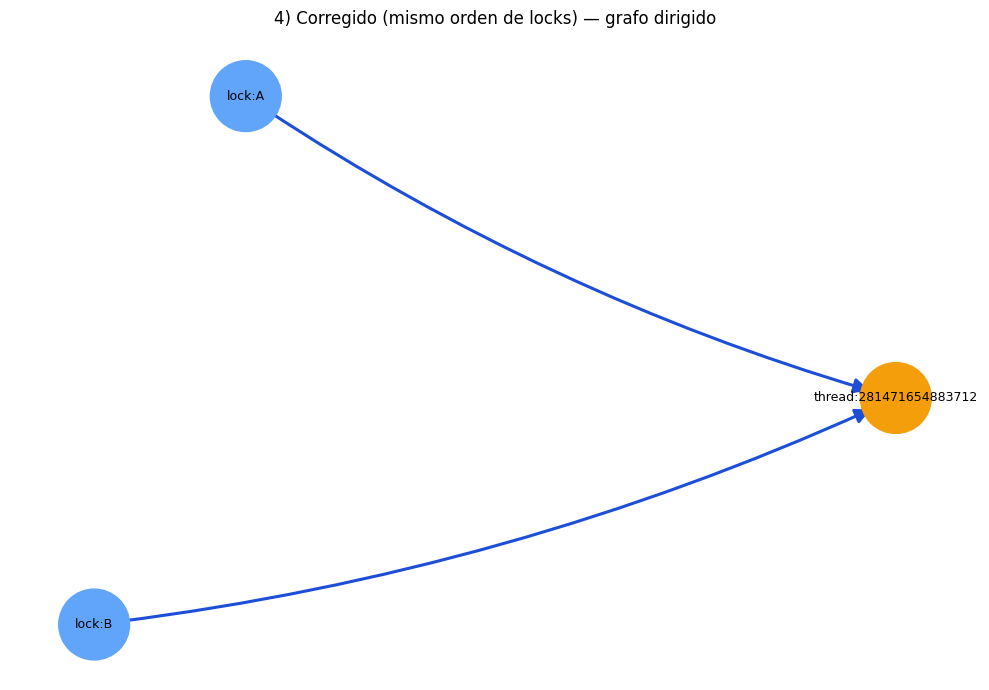

**Gantt (timeline de threads)**

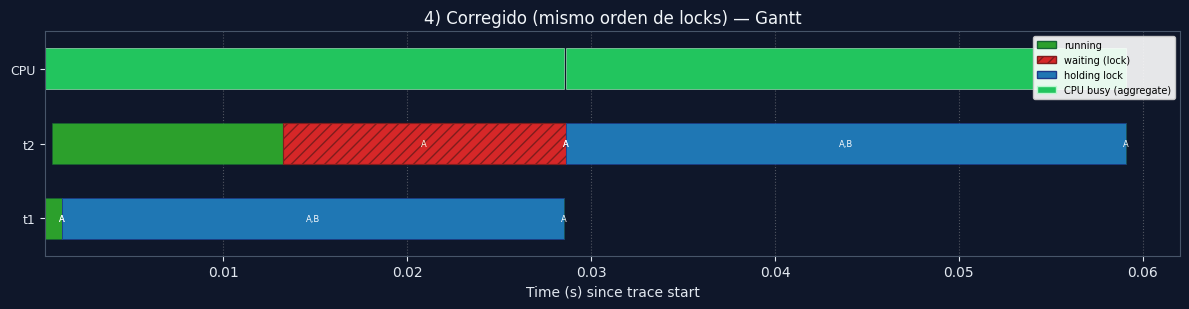

**¿Qué aprendimos?** **Insight:** un orden global elimina el ciclo clásico. **Por qué importa:** patrón muy común en migraciones de código. **En producción:** dos recursos (DB + cache) tomados en distinto orden.

In [5]:
# 4) Deadlock clásico + corrección
A = tl.TrackedLock("A")
B = tl.TrackedLock("B")

def t1_bad() -> None:
    A.acquire()
    time.sleep(0.035)
    try:
        B.acquire(timeout=0.35)
        if B.locked():
            B.release()
    finally:
        if A.locked():
            A.release()

def t2_bad() -> None:
    B.acquire()
    time.sleep(0.035)
    try:
        A.acquire(timeout=0.35)
        if A.locked():
            A.release()
    finally:
        if B.locked():
            B.release()

bad = run_thread_scenario([("t1", t1_bad), ("t2", t2_bad)], snapshot_delay=0.07)
show_thread_results("4) Deadlock clásico (orden cruzado)", bad)
print("\\n>>> Corrección sugerida: orden global A → B\\n")

def fixed_pair(d: float) -> None:
    time.sleep(d)
    A.acquire()
    B.acquire()
    try:
        time.sleep(0.025)
    finally:
        B.release()
        A.release()

good = run_thread_scenario(
    [("t1", lambda: fixed_pair(0.0)), ("t2", lambda: fixed_pair(0.012))],
    snapshot_delay=0.04,
)
show_thread_results("4) Corregido (mismo orden de locks)", good)
learned(
    "**Insight:** un orden global elimina el ciclo clásico. "
    "**Por qué importa:** patrón muy común en migraciones de código. "
    "**En producción:** dos recursos (DB + cache) tomados en distinto orden."
)


## 5) Deadlock complejo (3+ nodos)

**Contexto:** Tres locks y tres hilos formando un ciclo mayor.

**Comportamiento esperado:** Ciclo más rico en el grafo; corrección por política de adquisición.

**Qué mirar:** Visualización estructural clara vs. logs planos.


### 5) Deadlock complejo (ciclo largo)

**Resumen (snapshot en caliente):** thread 281471654883712 (w1) holds lock 'L1'; thread 281471654883712 (w1) waits for lock 'L2'; thread 281471665369472 (w2) holds lock 'L2'; thread 281471665369472 (w2) waits for lock 'L3'; thread 281471675855232 (w3) holds lock 'L3'; thread 281471675855232 (w3) waits for lock 'L1'

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

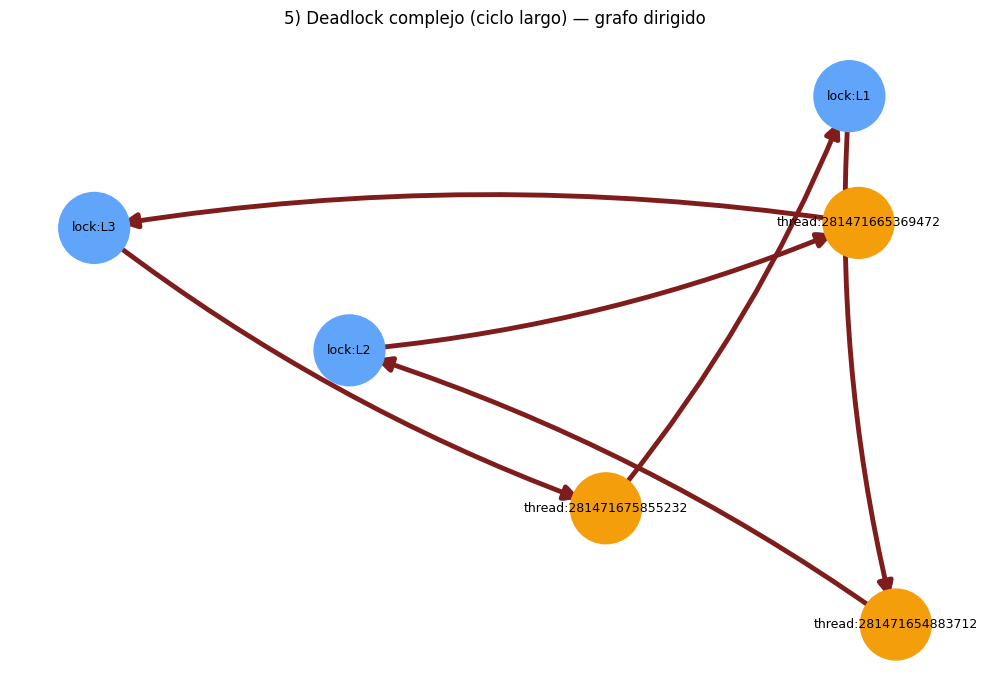

**Gantt (timeline de threads)**

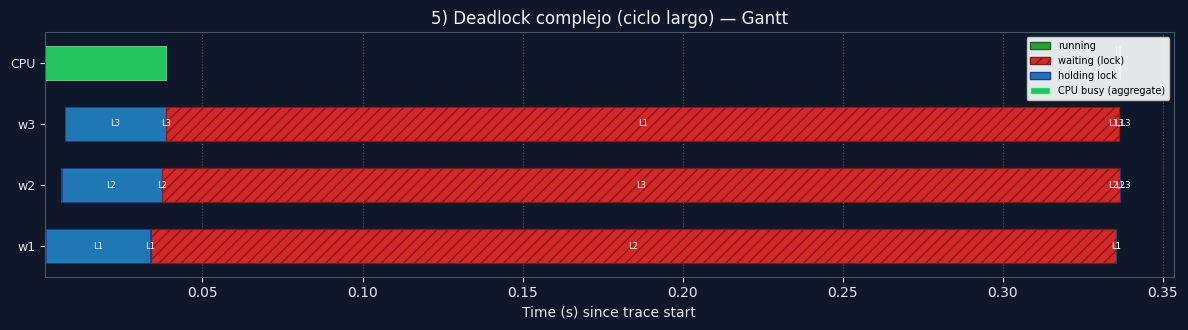

\n>>> Corrección: adquirir siempre L1 → L2 → L3\n


### 5) Corregido (cadena ordenada)

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

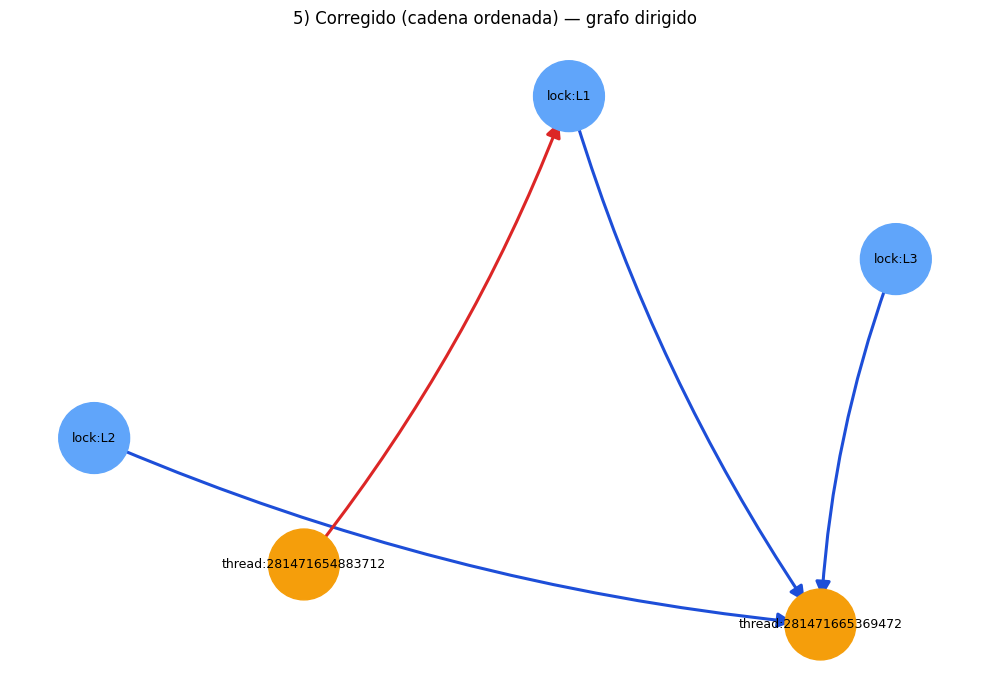

**Gantt (timeline de threads)**

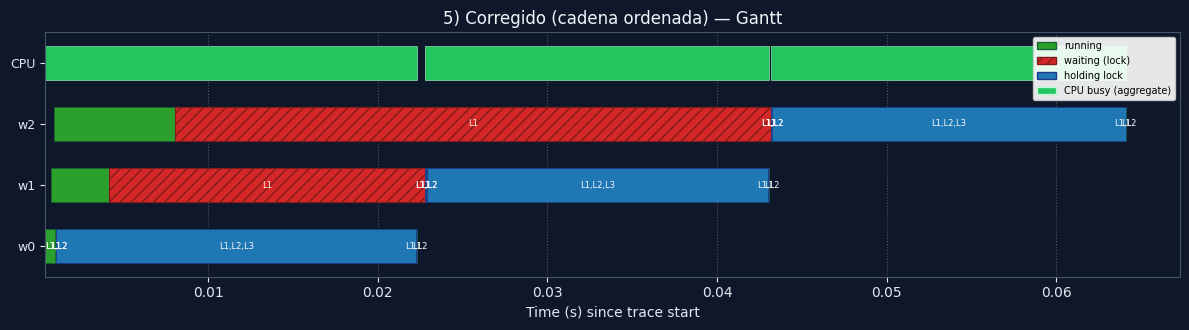

**¿Qué aprendimos?** **Insight:** ciclos grandes son difíciles de ver en logs; el grafo los resume. **Por qué importa:** equipos grandes, muchos módulos. **En producción:** microservicios que comparten locks lógicos (shard, tenant).

In [6]:
# 5) Deadlock complejo (3+ nodos) + corrección
L1 = tl.TrackedLock("L1")
L2 = tl.TrackedLock("L2")
L3 = tl.TrackedLock("L3")

def w1() -> None:
    L1.acquire()
    time.sleep(0.03)
    try:
        L2.acquire(timeout=0.3)
        if L2.locked():
            L2.release()
    finally:
        if L1.locked():
            L1.release()

def w2() -> None:
    L2.acquire()
    time.sleep(0.03)
    try:
        L3.acquire(timeout=0.3)
        if L3.locked():
            L3.release()
    finally:
        if L2.locked():
            L2.release()

def w3() -> None:
    L3.acquire()
    time.sleep(0.03)
    try:
        L1.acquire(timeout=0.3)
        if L1.locked():
            L1.release()
    finally:
        if L3.locked():
            L3.release()

bad = run_thread_scenario([("w1", w1), ("w2", w2), ("w3", w3)], snapshot_delay=0.07)
show_thread_results("5) Deadlock complejo (ciclo largo)", bad)
print("\\n>>> Corrección: adquirir siempre L1 → L2 → L3\\n")

def fixed_chain(d: float) -> None:
    time.sleep(d)
    L1.acquire()
    L2.acquire()
    L3.acquire()
    try:
        time.sleep(0.02)
    finally:
        L3.release()
        L2.release()
        L1.release()

good = run_thread_scenario(
    [(f"w{i}", lambda i=i: fixed_chain(0.003 * i)) for i in range(3)],
    snapshot_delay=0.03,
)
show_thread_results("5) Corregido (cadena ordenada)", good)
learned(
    "**Insight:** ciclos grandes son difíciles de ver en logs; el grafo los resume. "
    "**Por qué importa:** equipos grandes, muchos módulos. "
    "**En producción:** microservicios que comparten locks lógicos (shard, tenant)."
)


## 6) Locks anidados (riesgo sin fallo inmediato)

**Contexto:** Config → DB → caché en anidación profunda.

**Comportamiento esperado:** Hoy funciona; mañana un refactor puede cerrar el ciclo.

**Qué mirar:** Observa profundidad y solapamiento de secciones críticas.


### 6) Locks anidados (sin fallo inmediato)

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

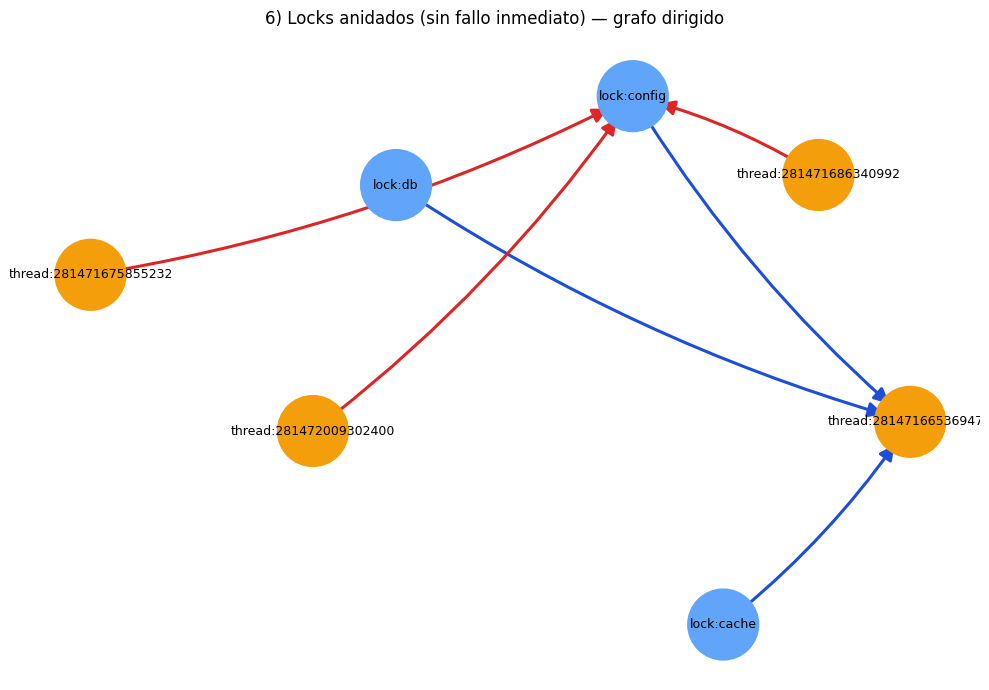

**Gantt (timeline de threads)**

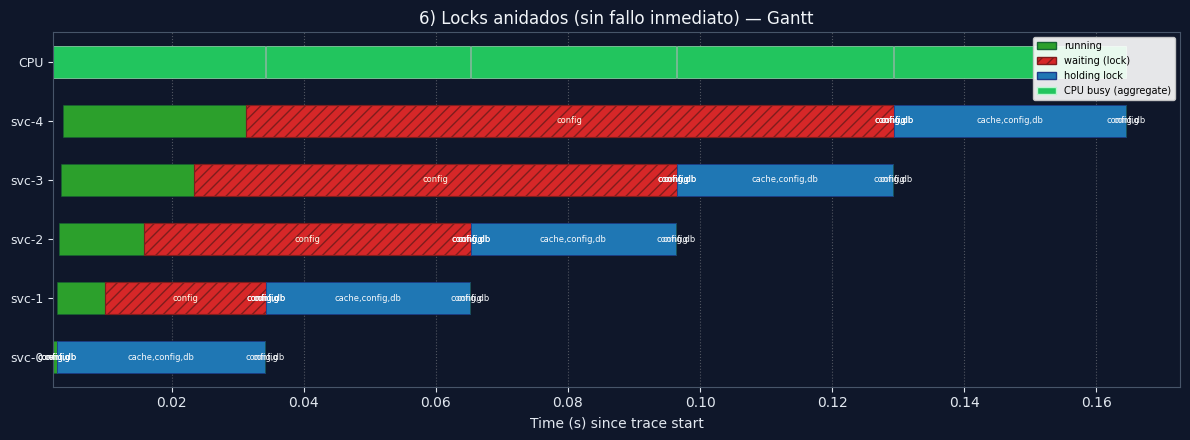

**¿Qué aprendimos?** **Insight:** profundidad de locking = deuda de incidentes. **Por qué importa:** un refactor puede crear un ciclo donde antes no había. **En producción:** inicialización en cascada (config → DB → cache).

In [7]:
# 6) Locks anidados (riesgo estructural)
cfg = tl.TrackedLock("config")
db = tl.TrackedLock("db")
cache = tl.TrackedLock("cache")

def nested_stack(i: int) -> None:
    time.sleep(0.006 * i)
    cfg.acquire()
    try:
        db.acquire()
        try:
            cache.acquire()
            try:
                time.sleep(0.03)
            finally:
                cache.release()
        finally:
            db.release()
    finally:
        cfg.release()

r6 = run_thread_scenario(
    [(f"svc-{i}", lambda i=i: nested_stack(i)) for i in range(5)],
    snapshot_delay=0.045,
)
show_thread_results("6) Locks anidados (sin fallo inmediato)", r6)
learned(
    "**Insight:** profundidad de locking = deuda de incidentes. "
    "**Por qué importa:** un refactor puede crear un ciclo donde antes no había. "
    "**En producción:** inicialización en cascada (config → DB → cache)."
)


## 7) Inversión de prioridades (simulada)

**Contexto:** Un hilo «lento» ocupa el mutex antes que el «rápido».

**Comportamiento esperado:** El crítico espera aunque su lógica sea corta.

**Qué mirar:** Medimos espera explícita; diseño subóptimo.


### 7) Inversión de prioridades

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

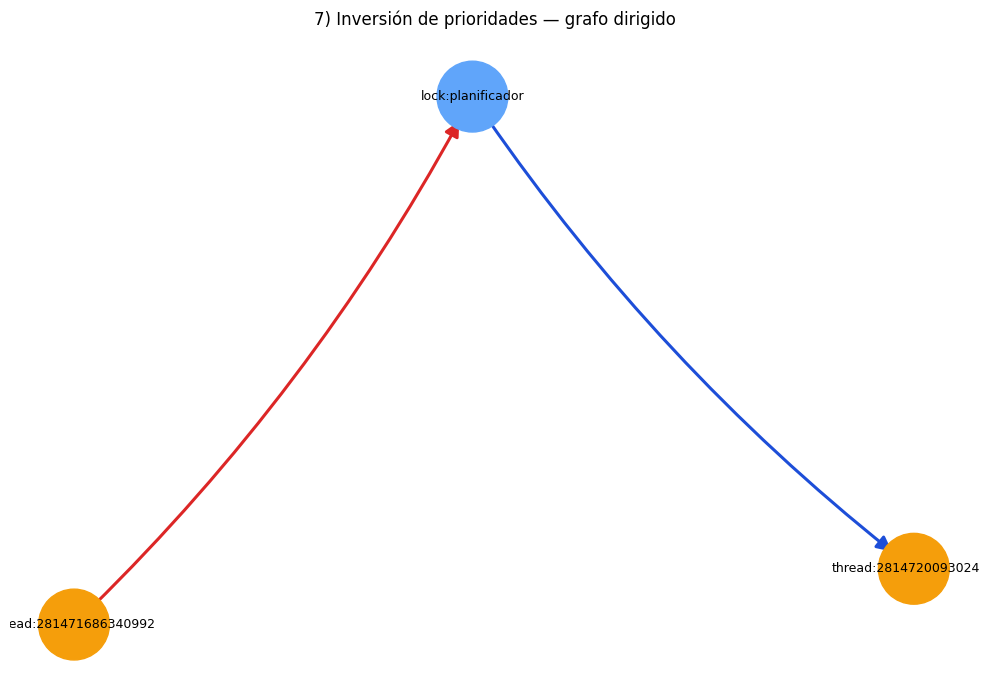

**Gantt (timeline de threads)**

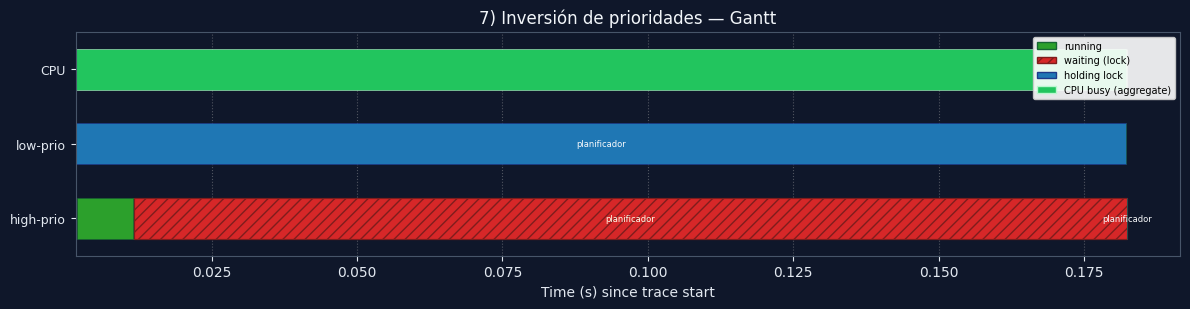

Espera del thread rápido: 0.171 s


**¿Qué aprendimos?** **Insight:** la prioridad de negocio no basta si comparten un mutex. **Por qué importa:** SLAs de endpoints críticos. **En producción:** tareas batch vs. requests interactivos en el mismo lock.

In [8]:
# 7) Inversión de prioridades (simulada)
sched = tl.TrackedLock("planificador")
wait_hi = {}

def low_priority() -> None:
    sched.acquire()
    try:
        time.sleep(0.18)
    finally:
        sched.release()

def high_priority() -> None:
    time.sleep(0.008)
    t0 = time.perf_counter()
    sched.acquire()
    try:
        wait_hi["s"] = time.perf_counter() - t0
    finally:
        sched.release()

r7 = run_thread_scenario(
    [("low-prio", low_priority), ("high-prio", high_priority)],
    snapshot_delay=0.045,
)
show_thread_results("7) Inversión de prioridades", r7)
print(f"Espera del thread rápido: {wait_hi.get('s', 0):.3f} s")
learned(
    "**Insight:** la prioridad de negocio no basta si comparten un mutex. "
    "**Por qué importa:** SLAs de endpoints críticos. "
    "**En producción:** tareas batch vs. requests interactivos en el mismo lock."
)


## 8) Async básico

**Contexto:** Tareas asyncio con `await` (I/O simulado).

**Comportamiento esperado:** Sin bloqueo de hilos OS; esperas cooperativas visibles.

**Qué mirar:** Gantt async y grafo de dependencias liviano.


### 8) Async básico

*Async* · dependencias entre tasks · `tl.visualize`

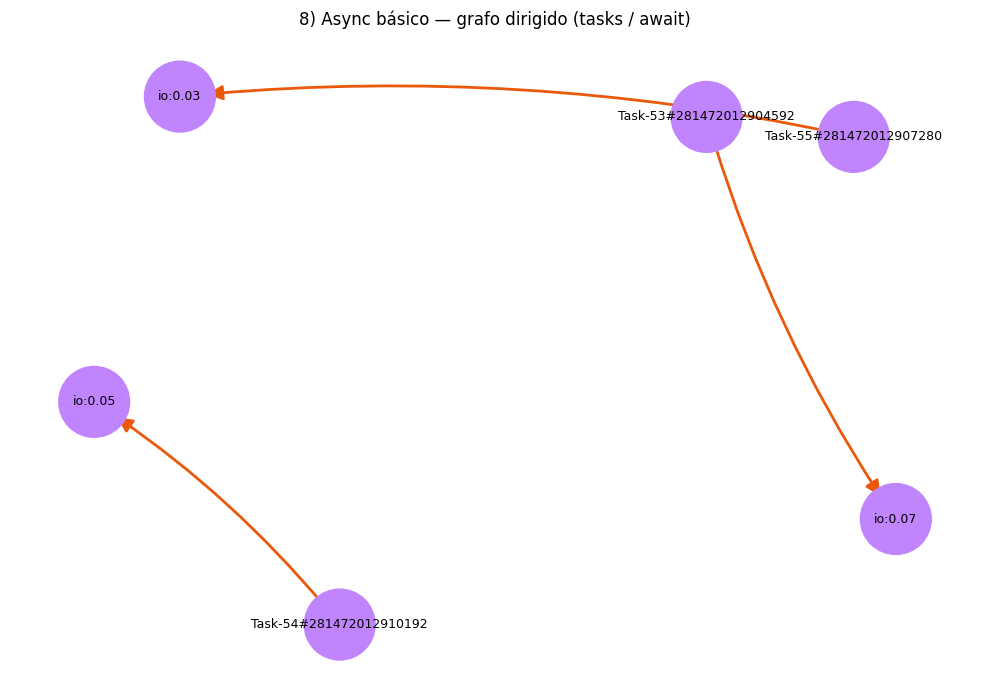

**Gantt async**

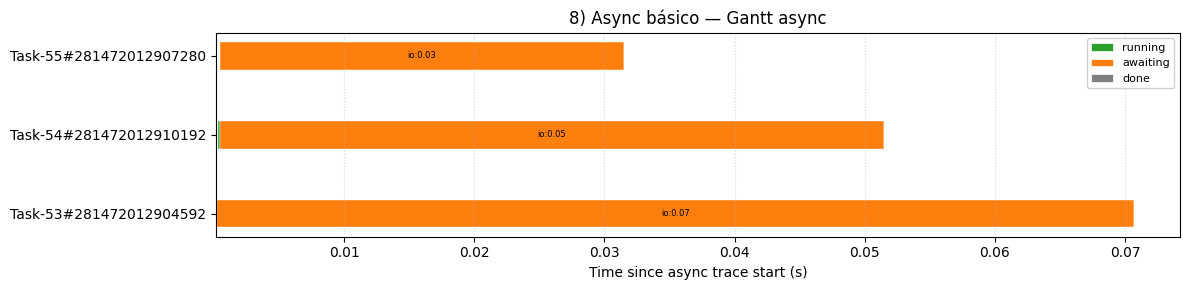

**¿Qué aprendimos?** **Insight:** async hace explícitas las esperas cooperativas. **Por qué importa:** throughput sin bloquear hilos del SO. **En producción:** gateways y I/O-bound services.

In [9]:
# 8) Async básico
@tl.trace_async
async def io_task(name: str, delay: float) -> str:
    await tl.traced_await(asyncio.sleep(delay), awaiting=f"io:{delay}")
    return name

async def run_async_basic():
    reset_state()
    tl.start_async_tracing(clear=True)
    try:
        await asyncio.gather(
            io_task("alpha", 0.07),
            io_task("beta", 0.05),
            io_task("gamma", 0.03),
        )
    finally:
        tl.stop_async_tracing()
    return list(tl.get_async_events())

ev8 = run_coro_notebook_safe(run_async_basic())
show_async_results("8) Async básico", ev8)
learned(
    "**Insight:** async hace explícitas las esperas cooperativas. "
    "**Por qué importa:** throughput sin bloquear hilos del SO. "
    "**En producción:** gateways y I/O-bound services."
)


## 9) Async con dependencia

**Contexto:** Una task agrega resultados de otras (`gather` / `create_task`).

**Comportamiento esperado:** La latencia total sigue la cadena de dependencias.

**Qué mirar:** Útil para ver qué paralelizar primero.


### 9) Async con dependencias entre tasks

*Async* · dependencias entre tasks · `tl.visualize`

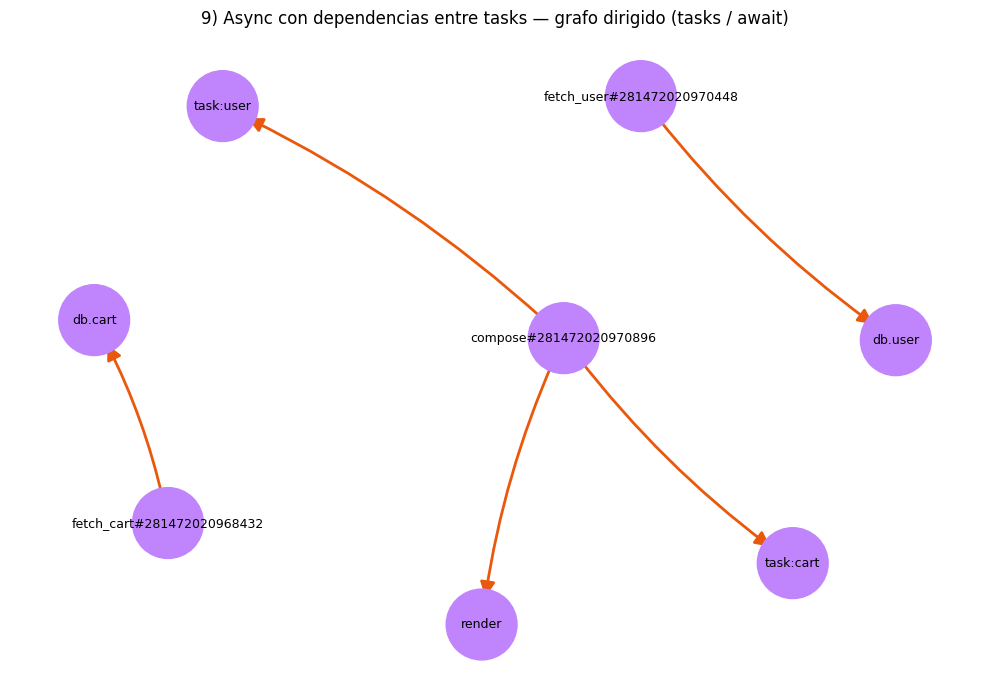

**Gantt async**

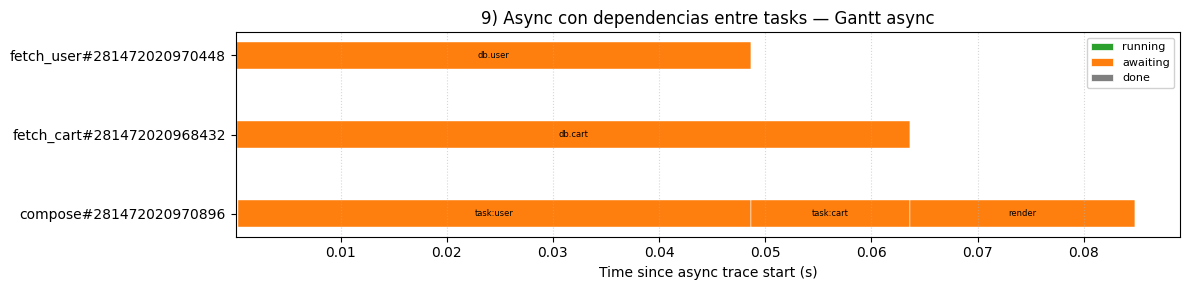

**¿Qué aprendimos?** **Insight:** el camino crítico lo marcan dependencias de negocio. **Por qué importa:** paralelizar lo correcto primero. **En producción:** BFFs que agregan fuentes.

In [10]:
# 9) Async con dependencias entre tasks
@tl.trace_async
async def fetch_user():
    await tl.traced_await(asyncio.sleep(0.045), awaiting="db.user")
    return {"id": 1}

@tl.trace_async
async def fetch_cart():
    await tl.traced_await(asyncio.sleep(0.06), awaiting="db.cart")
    return {"items": []}

@tl.trace_async
async def compose(u_task, c_task):
    u = await tl.traced_await(u_task, awaiting="task:user")
    c = await tl.traced_await(c_task, awaiting="task:cart")
    await tl.traced_await(asyncio.sleep(0.018), awaiting="render")
    return u, c

async def run_async_dep():
    reset_state()
    tl.start_async_tracing(clear=True)
    try:
        ut = asyncio.create_task(fetch_user(), name="fetch_user")
        ct = asyncio.create_task(fetch_cart(), name="fetch_cart")
        main = asyncio.create_task(compose(ut, ct), name="compose")
        await main
    finally:
        tl.stop_async_tracing()
    return list(tl.get_async_events())

ev9 = run_coro_notebook_safe(run_async_dep())
show_async_results("9) Async con dependencias entre tasks", ev9)
learned(
    "**Insight:** el camino crítico lo marcan dependencias de negocio. "
    "**Por qué importa:** paralelizar lo correcto primero. "
    "**En producción:** BFFs que agregan fuentes."
)


## 10) Mini sistema real (final)

**Contexto:** Requests concurrentes: caché + DB con locks distintos.

**Comportamiento esperado:** Contención realista; métricas de latencia.

**Qué mirar:** Diagnóstico completo con threadle antes de optimizar a ciegas.


### 10) Mini sistema real

**Resumen (snapshot en caliente):** no wait-for cycle at this snapshot

**Resumen (snapshot final):** no wait-for cycle at this snapshot

**Grafo wait-for** (`tl.visualize`): grafo **dirigido** (aristas con flecha). Flechas: lock → thread (posee) y thread → lock (espera).

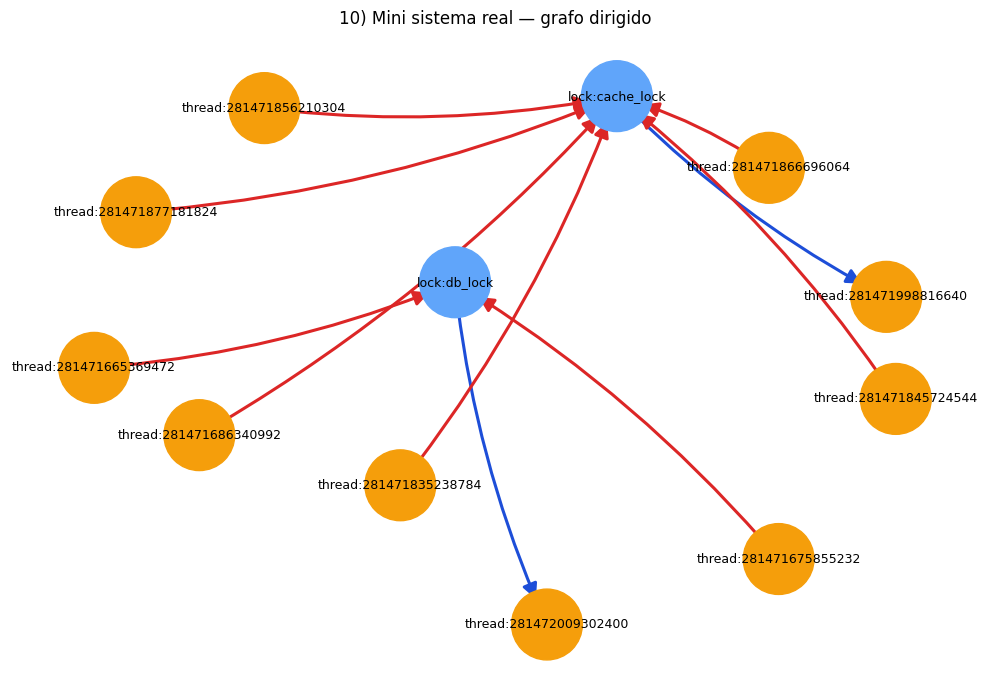

**Gantt (timeline de threads)**

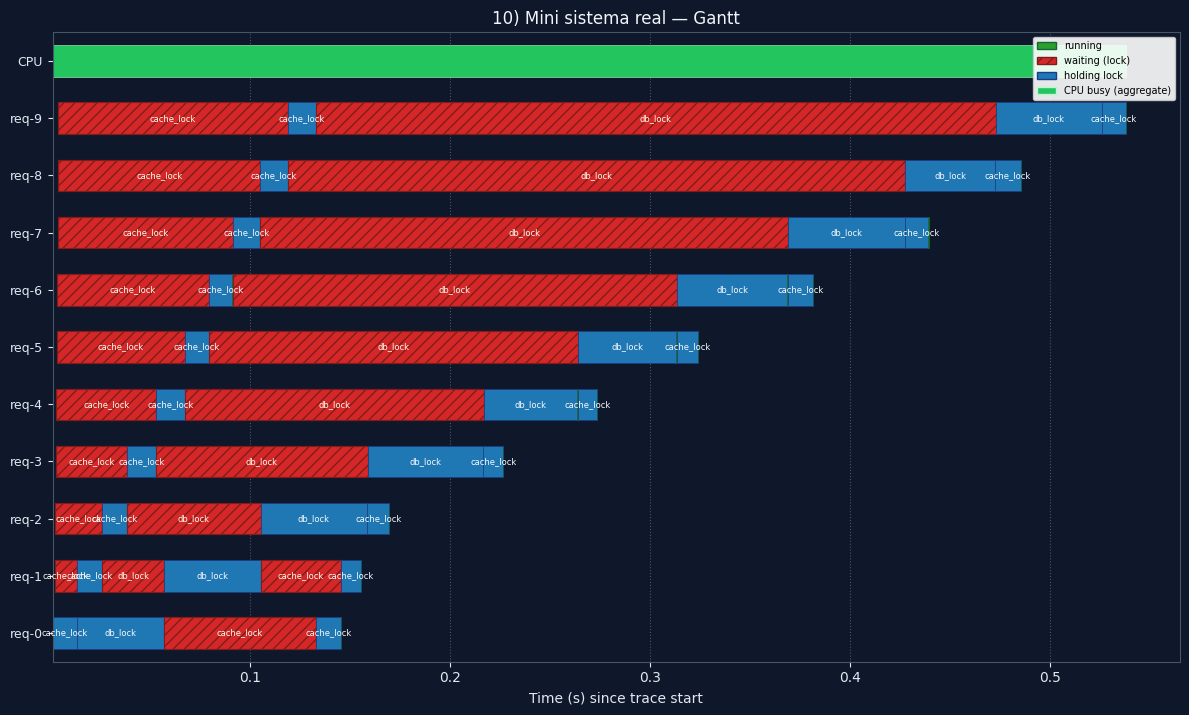

Latencia media: 0.311s | ~p95: 0.482s


**¿Qué aprendimos?** **Insight:** contención real sin deadlock sigue doliendo en latencia. **Por qué importa:** prioriza qué lock/partición optimizar. **En producción:** APIs con lectura de caché + escritura a DB.

In [11]:
# 10) Mini sistema real (DB + caché)
db_lock = tl.TrackedLock("db_lock")
cache_lock = tl.TrackedLock("cache_lock")
latencies = []

def handle_request(rid: int) -> None:
    t0 = time.perf_counter()
    cache_lock.acquire()
    try:
        time.sleep(0.011)
    finally:
        cache_lock.release()
    db_lock.acquire()
    try:
        time.sleep(0.042 + 0.005 * (rid % 4))
    finally:
        db_lock.release()
    cache_lock.acquire()
    try:
        time.sleep(0.009)
    finally:
        cache_lock.release()
    latencies.append(time.perf_counter() - t0)

r10 = run_thread_scenario(
    [(f"req-{i}", lambda i=i: handle_request(i)) for i in range(10)],
    snapshot_delay=0.055,
    join_timeout=5.0,
)
show_thread_results("10) Mini sistema real", r10)
lat = sorted(latencies)
idx = max(0, min(len(lat) - 1, int(0.95 * len(lat)) - 1))
print(f"Latencia media: {sum(lat)/len(lat):.3f}s | ~p95: {lat[idx]:.3f}s")
learned(
    "**Insight:** contención real sin deadlock sigue doliendo en latencia. "
    "**Por qué importa:** prioriza qué lock/partición optimizar. "
    "**En producción:** APIs con lectura de caché + escritura a DB."
)


## Conclusión

Has recorrido **diez escenarios** de lo sano a lo crítico, threads y asyncio, hasta un mini backend.

**Próximos pasos en producción:** exportar `export_debug_bundle_json()` en CI o post-mortems; comparar snapshots entre versiones; usar el CLI (`threadle detect`, `threadle snapshot`) donde encaje.

**Exportar este notebook a HTML** (después de `pip install -e ".[dev]"`):

```bash
python -m nbconvert notebook/demo.ipynb --to html --output demo.html
```


## Automated validation

Fragmentos esperados por la suite de tests: `run_demo`, PNGs bajo `outputs/`, y referencias a **Escenario A**, **Escenario B**, **Escenario C**, **Escenario K**.

También documentamos el entrypoint `threadle.cli.main` (módulo equivalente al comando `threadle` cuando está instalado).


### Escenario A — snapshot de grafo (CI)

Escribe `outputs/scenario-a-wait-graph.png`.

### Escenario B — segundo grafo bajo contención

Escribe `outputs/scenario-b-wait-graph.png`.

### Escenario C — exports Gantt (threads)

Genera `outputs/demo-wait-graph.png` y `outputs/demo-gantt.png` usando `export_gantt`.

### Escenario K — Gantt async

Exporta `outputs/demo-async-gantt.png` con `export_async_gantt`.


In [12]:
# --- Artefactos para documentación y CI (no forma parte de los 10 escenarios)
from pathlib import Path

from threadle.examples.deadlock_demo import run_demo

Path("outputs").mkdir(parents=True, exist_ok=True)

# Paquete JSON (útil en incidentes)
print(tl.export_debug_bundle_json()[:400], "...")

# CLI (mismo entrypoint que `threadle` cuando está instalado como consola)
# python -m threadle.cli.main -h

# Demo empaquetado → grafo estándar del proyecto
run_demo(visualize_graph=True, output_path="outputs/showcase-run-demo.png")

# Escenario A: grafo mínimo exportado
reset_state()
with tl.Session(trace_timeline=True, reset_tracker=True):
    L = tl.TrackedLock("A_only")

    def hold():
        L.acquire()
        time.sleep(0.08)

    th = threading.Thread(target=tl.trace_thread(hold), name="ci-A")
    th.start()
    time.sleep(0.02)
    tl.visualize(output_path="outputs/scenario-a-wait-graph.png")
    th.join(timeout=1.0)

# Escenario B: segundo snapshot
reset_state()
with tl.Session(trace_timeline=True, reset_tracker=True):
    X = tl.TrackedLock("B_x")
    Y = tl.TrackedLock("B_y")

    def b1():
        X.acquire()
        time.sleep(0.02)
        Y.acquire(timeout=0.15)
        if Y.locked():
            Y.release()
        if X.locked():
            X.release()

    def b2():
        Y.acquire()
        time.sleep(0.02)
        X.acquire(timeout=0.15)
        if X.locked():
            X.release()
        if Y.locked():
            Y.release()

    t1 = threading.Thread(target=tl.trace_thread(b1), name="ci-B1")
    t2 = threading.Thread(target=tl.trace_thread(b2), name="ci-B2")
    t1.start()
    t2.start()
    time.sleep(0.05)
    tl.visualize(output_path="outputs/scenario-b-wait-graph.png")
    t1.join(timeout=0.5)
    t2.join(timeout=0.5)

# Escenario C + exports Gantt sync
reset_state()
with tl.Session(trace_timeline=True, reset_tracker=True):
    lk = tl.TrackedLock("gantt_demo")

    def worker(d: float):
        time.sleep(d)
        lk.acquire()
        try:
            time.sleep(0.04)
        finally:
            lk.release()

    threading.Thread(target=tl.trace_thread(lambda: worker(0.0)), name="c1").start()
    threading.Thread(target=tl.trace_thread(lambda: worker(0.02)), name="c2").start()
    time.sleep(0.06)
    ev = list(tl.get_events())
    tl.visualize(output_path="outputs/demo-wait-graph.png")
    tl.export_gantt("outputs/demo-gantt.png", events=ev, palette="semantic", theme="dark")

# Escenario K — async Gantt exportado
@tl.trace_async
async def k_task():
    await tl.traced_await(asyncio.sleep(0.05), awaiting="k_io")

async def run_k():
    reset_state()
    tl.start_async_tracing(clear=True)
    try:
        await k_task()
    finally:
        tl.stop_async_tracing()
    return list(tl.get_async_events())

kev = run_coro_notebook_safe(run_k())
tl.export_async_gantt("outputs/demo-async-gantt.png", events=kev)

print("Artefactos escritos bajo outputs/")


{
  "tracker": {
    "locks": {
      "cache_lock": {
        "name": "cache_lock",
        "owner": null,
        "waiting": []
      },
      "db_lock": {
        "name": "db_lock",
        "owner": null,
        "waiting": []
      }
    },
    "threads": {
      "281471686340992": {
        "ident": 281471686340992,
        "name": "req-0",
        "waiting_for": null
      },
      "281472009 ...
Artefactos escritos bajo outputs/
